# Imports

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from scipy import stats as sc
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import truncnorm
import os

/Users/zc/micromamba/envs/chen5150/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


# Plot Styling

In [2]:
os.makedirs("figures", exist_ok=True)

plt.style.use("ggplot")
plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "font.size":       11,
    "axes.titlesize":  13,
    "axes.labelsize":   12,
    "figure.dpi":      400,
    "lines.linewidth":  2.0,
    "axes.spines.top":   False,
    "axes.spines.bottom": True,
    "axes.spines.left":  True,
    "axes.spines.right":  False,
    "axes.grid":         False,
    "grid.linestyle":   "--",
    "figure.facecolor": "none",   # transparent figure background
    "axes.facecolor":   "none",   # transparent axes background
    "savefig.facecolor": "none",  # transparent when saving
    "savefig.transparent": True,  # ensure transparency in output file
})

COLORS = [
    "#f94144",
    "#f3722c",
    "#f8961e",
    "#f9844a",
    "#f9c74f",
    "#90be6d",
    "#43aa8b",
    "#4d908e",
    "#577590",
    "#277da1"
]

# Parameters

In [3]:
# Derived structural constants
_LPA_fixed_kb  = 90.0   # non-KIV-2 pre-mRNA  [kb]
_KIV2_kb       = 5.5    # one KIV-2 repeat     [kb]
_RNAP_nt_s     = 40.0   # RNA pol elongation   [nt/s]
_aa_per_kr     = 80     # aa per kringle domain
_n_rib         = 5      # ribosomes per mRNA (polysome)
_rib_aa_s      = 4.0    # ribosome elongation  [aa/s]

# N0_tx : non-KIV-2 gene in KIV-2-equivalent repeat units  (~16.4)
_N0_tx    = _LPA_fixed_kb / _KIV2_kb
# alpha_tx : inverse of elongation time per KIV-2-equivalent [hr^-1]  (~26.2)
_alpha_tx = (_RNAP_nt_s * 3600) / (_KIV2_kb * 1000)

# N0_prot : fixed kringle-equivalent domains (KIV1, KIV3-10, KV, protease) = 11
_N0_prot  = 11
# alpha_tl = n_rib * rib_aa_s * 3600 / aa_per_kr                             (900)
_alpha_tl = _n_rib * _rib_aa_s * 3600 / _aa_per_kr

params = {
    # Transcription  k_tx(n) = alpha_tx / (N0_tx + n)
    # Source: LPA genomic structure (90 kb fixed + 5.5 kb/repeat; RNAP at 40 nt/s)
    "alpha_tx": _alpha_tx,   # ~26.2 hr^-1·repeat
    "N0_tx":    _N0_tx,      # ~16.4

    # mRNA decay
    # Source: hepatic mRNA t1/2 ~ 6 h (Sharova 2009, Nat Methods)
    "k_deg_m": np.log(2) / 6.0,   # 0.1155 hr^-1

    # Translation  k_tl(n) = alpha_tl / (N0_prot + n)
    # Source: 5 ribosomes × 4 aa/s × 3600 s/hr / 80 aa per kringle
    "alpha_tl": _alpha_tl,   # 900 hr^-1
    "N0_prot":  _N0_prot,    # 11

    # ER folding/processing  k_fold(n) = k_fold0 / n
    # Each KIV-2 kringle: 3 disulfide bonds + N-glycosylation + chaperone cycling.
    # Calibrated: ~4 h ER processing at n=8 (Rouy 1992 HepG2 pulse-chase).
    "k_fold0": 2.0,          # hr^-1

    # ERAD — exponential (linear ODE model)
    # Mechanistic basis: per-kringle misfolding probability lam;
    #   secretion survival ~ (1-p)^n ≈ exp(-lam*n)  =>  ERAD rate ~ exp(lam*n)
    # lam and k_e calibrated to reproduce ~100-fold Lp(a) decrease n=5→35.
    "k_e":  0.10,   # hr^-1 (base ERAD rate, negligible for short isoforms)
    "lam":  0.07,   # per KIV-2 repeat  (posterior via Bayesian inference, §7)

    # ERAD — Michaelis-Menten (saturation / ER-stress analysis only)
    "V_ERAD_max": 5.0,   # hr^-1
    "K_M_ERAD":   1.0,   # a.u.

    # Lp(a) assembly — isoform-length-dependent Hill function
    # Biological basis: apo(a) requires a minimum number of kringle domains to
    # correctly present the LDL-apoB binding interface before the Cys-4057
    # disulfide bond can form.  Very short isoforms (n≤4) lack sufficient
    # structure → reduced assembly → lower plasma Lp(a).
    # Mukamel 2021 (Science): log-linear KIV-2/Lp(a) relationship inverts
    # for n≤4; attenuates for n<12.  K_n_assem=8 sets η_a≈50% at n=8 (the
    # empirical transition point); Hill coefficient h=3 reflects cooperativity.
    "k_assem_max": 3.0,   # hr^-1 (max assembly rate; LDL-apoB pseudo-1st-order)
    "K_n_assem":   8.0,   # KIV-2 repeats at half-max assembly efficiency
    "h_assem":     3.0,   # Hill coefficient (cooperative structural threshold)
    "k_deg_S":     1.5,   # hr^-1 (clearance of circulating unassembled apo(a))

    # Plasma Lp(a) clearance (FCR)
    # Source: Rader 1994 — FCR 0.329±0.090 d^-1 (small) vs 0.306±0.079 d^-1
    #         (large); NOT significantly different.  Ma 2019 confirmed.
    "k_cl": 0.32 / 24.0,   # 0.01333 hr^-1
}

# Rate Functions

In [4]:
def k_tx(n, p):
    """mRNA synthesis rate [mRNA/hr]; limited by RNAP elongation time ~ (N0_tx+n)."""
    return p["alpha_tx"] / (p["N0_tx"] + n)

def k_tl(n, p):
    """Translation rate per mRNA; limited by ribosome transit time ~ (N0_prot+n)."""
    return p["alpha_tl"] / (p["N0_prot"] + n)

def k_fold(n, p):
    """ER processing rate [hr^-1]; n kringles fold sequentially."""
    return p["k_fold0"] / n

def k_ERAD_exp(n, p):
    """ERAD rate constant (exponential model) [hr^-1]."""
    return p["k_e"] * np.exp(p["lam"] * n)

def k_assem_n(n, p):
    """
    n-dependent Lp(a) assembly rate [hr^-1].

    Hill function: k_assem_max * (n/K_n)^h / (1 + (n/K_n)^h)

    Physical meaning: apo(a) must present a minimum number of KIV-2 kringle
    domains to productively engage LDL-apoB for covalent linkage.  Very short
    isoforms (n≤4) lack the structural scaffold → near-zero assembly →
    low plasma Lp(a), consistent with Mukamel 2021 (Science).
    """
    x = (n / p["K_n_assem"]) ** p["h_assem"]
    return p["k_assem_max"] * x / (1.0 + x)

def ERAD_flux_mm(E, n, p):
    """Michaelis-Menten ERAD flux [a.u./hr]; saturates at high ER load."""
    V = p["V_ERAD_max"] * np.exp(p["lam"] * n)
    return V * E / (p["K_M_ERAD"] + E)

# ODE System

In [5]:
def apoa_ode(t, y, n, p, erad_model="exp"):
    """
    RHS of the 4-compartment apo(a) biosynthesis ODE.

    State  y = [M, E, S, Plp]
      M   : mRNA
      E   : ER apo(a)
      S   : secreted apo(a)
      Plp : plasma Lp(a)

    erad_model : "exp"  first-order ERAD  k_ERAD(n) = k_e * exp(lam*n)
                 "mm"   Michaelis-Menten ERAD (saturating)
    """
    M, E, S, Plp = y

    f_tx    = k_tx(n, p)
    f_tl    = k_tl(n, p) * M
    f_fold  = k_fold(n, p) * E
    ka      = k_assem_n(n, p)
    f_assem = ka * S                     # apo(a) → plasma Lp(a) particle
    f_deg_S = p["k_deg_S"] * S           # unassembled apo(a) clearance
    f_ERAD  = k_ERAD_exp(n, p) * E if erad_model == "exp" else ERAD_flux_mm(E, n, p)

    dM   = f_tx   - p["k_deg_m"] * M
    dE   = f_tl   - f_fold - f_ERAD
    dS   = f_fold - f_assem - f_deg_S    # leaves via assembly OR degradation
    dPlp = f_assem - p["k_cl"] * Plp

    return [dM, dE, dS, dPlp]

# Steady State

In [6]:
def steady_state(n, p):
    """
    Closed-form SS for exponential ERAD model with n-dependent assembly.

    Derivation (all compartments set to zero):
      M_ss = k_tx / k_deg_m
      E_ss = k_tl * M_ss / (k_fold + k_ERAD)
      S_ss = k_fold * E_ss / (k_assem_n + k_deg_S)   ← assembly now competes
      P_ss = k_assem_n * S_ss / k_cl

    Two efficiencies:
      eta      = k_fold / (k_fold + k_ERAD)      ER secretion efficiency
      eta_assem = k_assem_n / (k_assem_n + k_deg_S)  extracellular assembly eff.
    """
    kt  = k_tx(n, p)
    kl  = k_tl(n, p)
    kf  = k_fold(n, p)
    ke  = k_ERAD_exp(n, p)
    ka  = k_assem_n(n, p)
    kds = p["k_deg_S"]

    M   = kt / p["k_deg_m"]
    E   = kl * M / (kf + ke)
    S   = kf * E / (ka + kds)
    Plp = ka * S / p["k_cl"]

    eta       = kf / (kf + ke)      # ER secretion efficiency
    eta_assem = ka / (ka + kds)     # extracellular assembly efficiency

    return {"M": M, "E": E, "S": S, "P": Plp, "eta": eta, "eta_assem": eta_assem}


def steady_state_mm(n, p):
    """
    Closed-form (quadratic) SS for Michaelis-Menten ERAD model.
    Solves: A - F*E - V*E/(K+E) = 0  =>  F*E^2 + (FK+V-A)*E - AK = 0
    """
    M  = k_tx(n, p) / p["k_deg_m"]
    A  = k_tl(n, p) * M
    F  = k_fold(n, p)
    V  = p["V_ERAD_max"] * np.exp(p["lam"] * n)
    K  = p["K_M_ERAD"]

    b    = F * K + V - A
    disc = b**2 + 4 * F * A * K
    E    = (-b + np.sqrt(disc)) / (2 * F)
    ka   = k_assem_n(n, p)
    kds  = p["k_deg_S"]
    S    = F * E / (ka + kds)
    Plp  = ka * S / p["k_cl"]

    return {"M": M, "E": E, "S": S, "P": Plp, "eta": F * E / A,
            "eta_assem": ka / (ka + kds), "A": A, "V": V}

# Helper Functions

In [7]:
def chi2_gof_p_value(obs, pred, err, ddof=0):
    chi2_stat = np.sum(((obs - pred) / err) ** 2)
    dof = len(obs) - 1 - ddof
    p_val = sc.chi2.sf(chi2_stat, dof)
    return chi2_stat, p_val


def letter_tag(ax, letter):
    ax.text(-0.10, 1.06, letter, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="right", color="gray")

# Figure 1

/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_56602/3444415123.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ks" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(obs_n_r, obs_PR_r, yerr=obs_err_r, fmt="ks", ms=6, capsize=4,


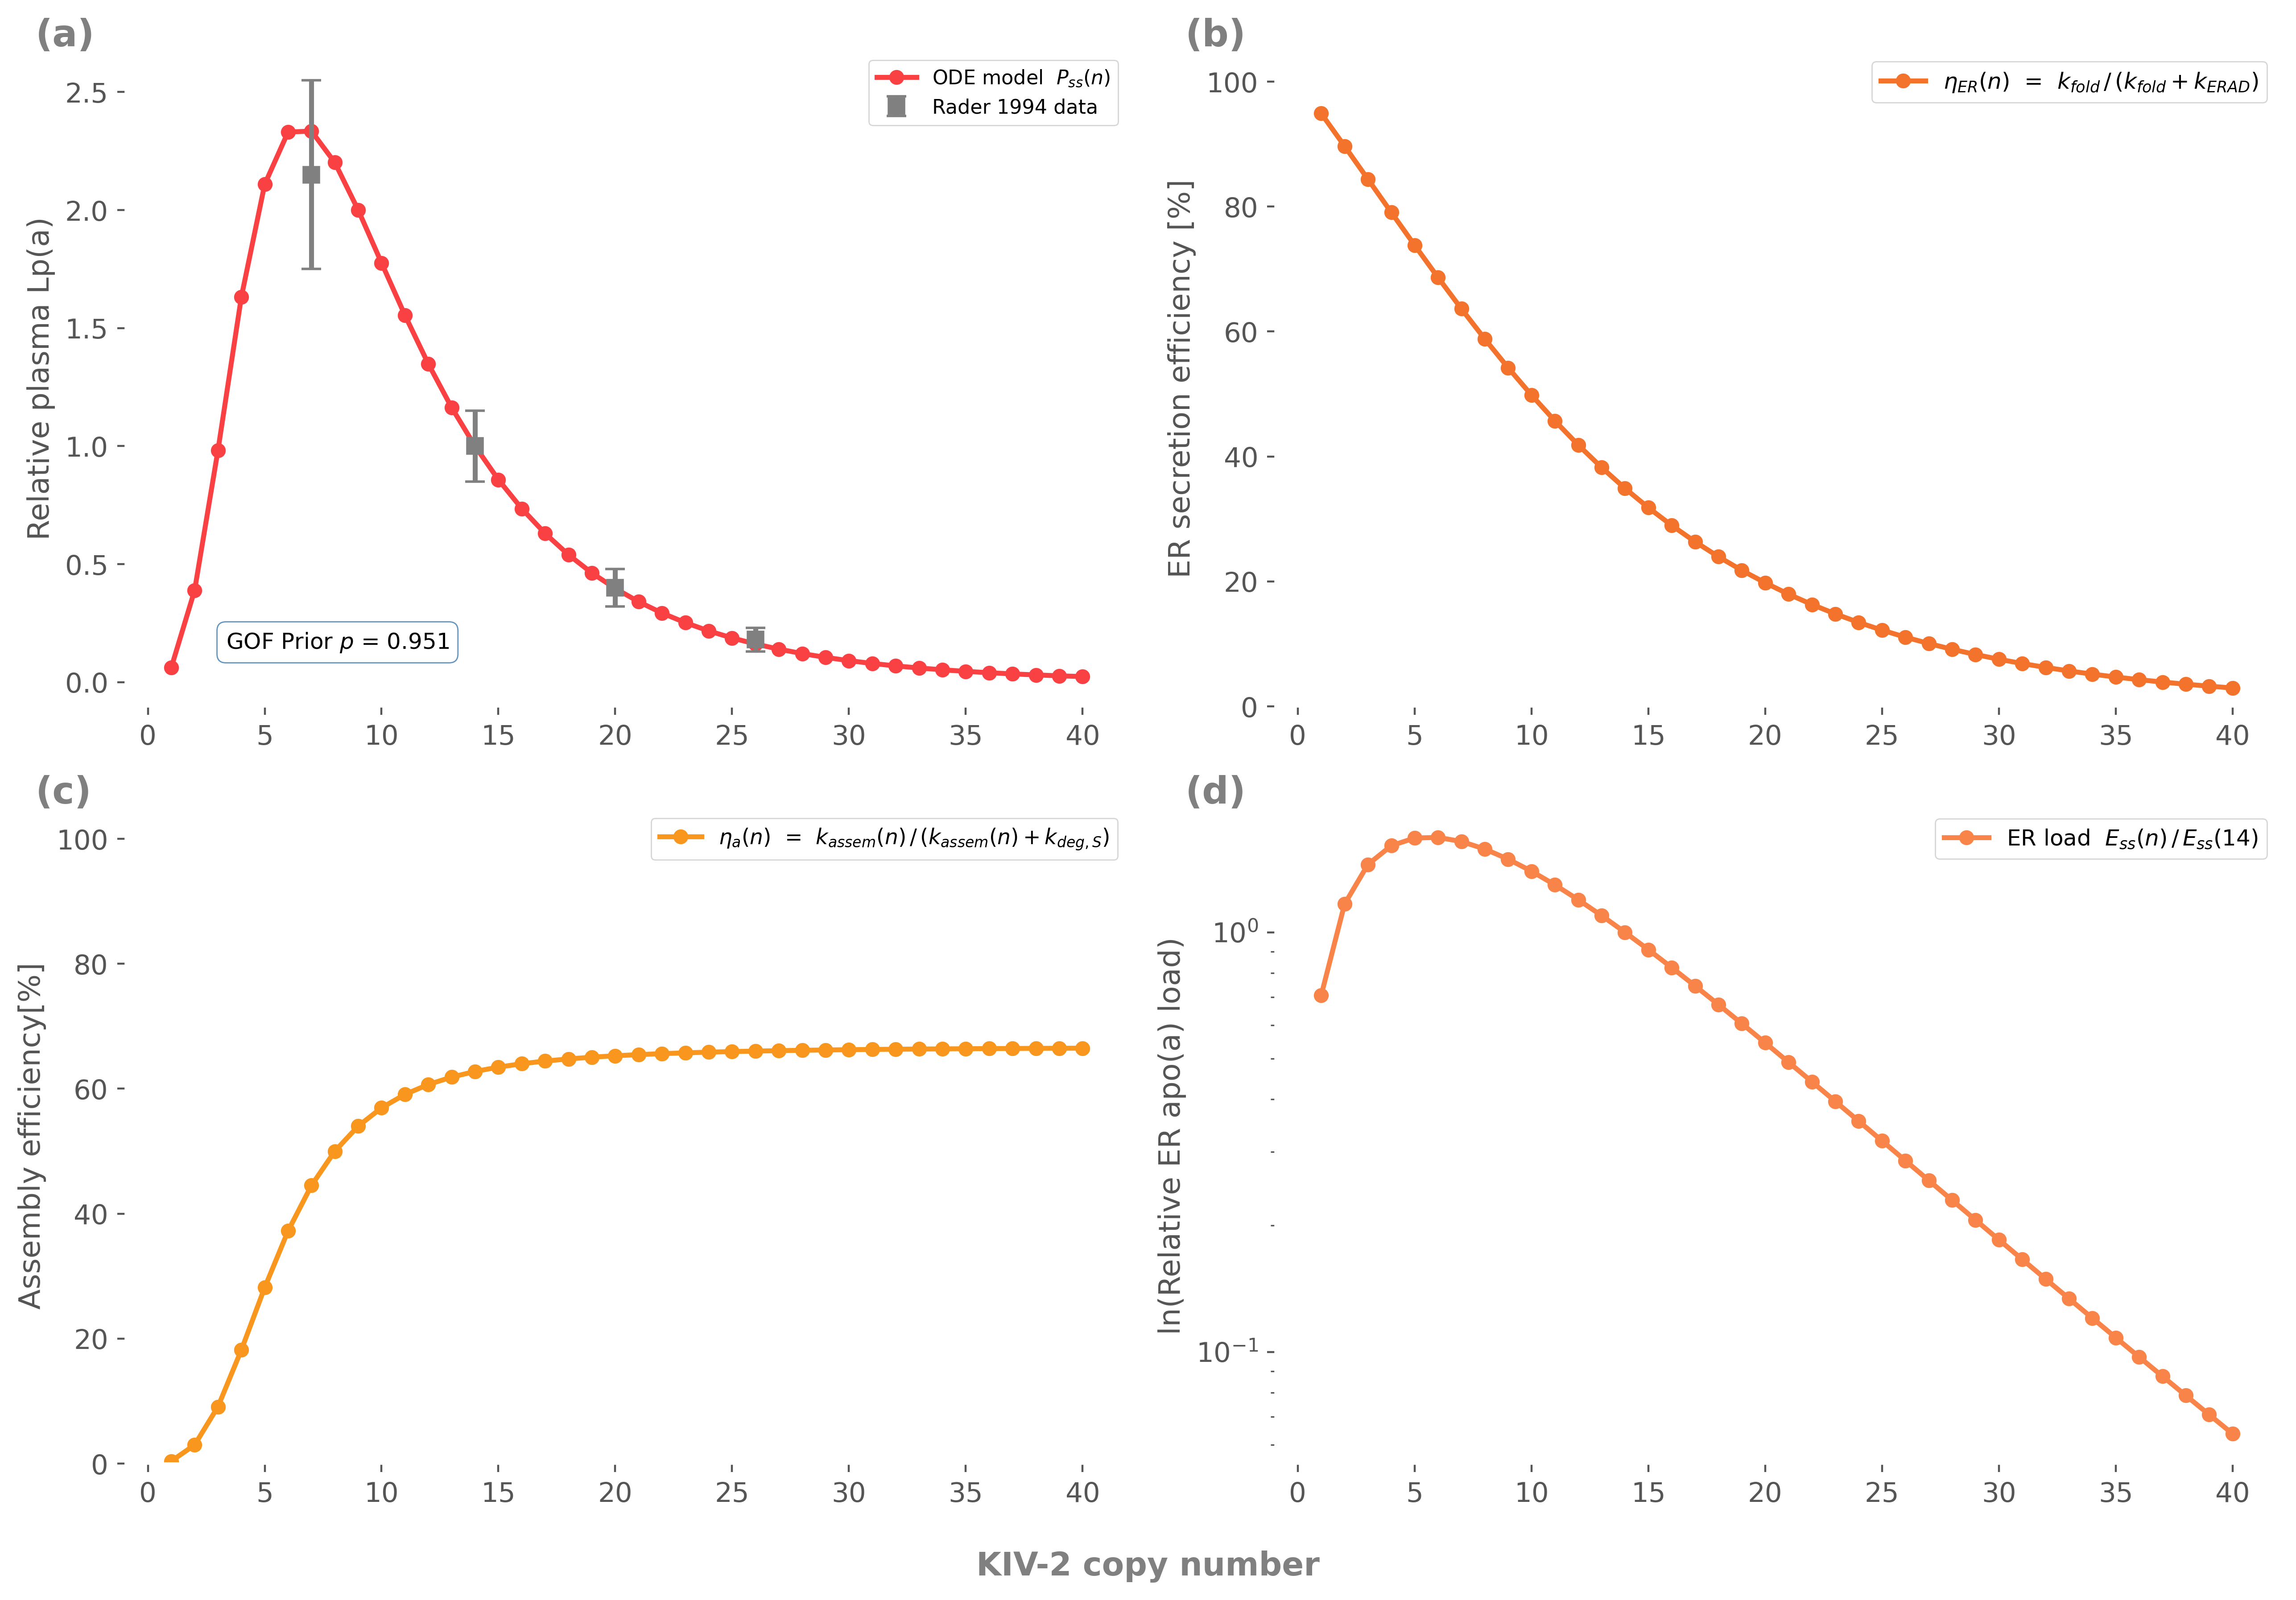

In [15]:

n_arr   = np.arange(1, 41)
REF_N   = 14        # normalize to n=14 (Rader 1994 S2 isoform reference)
ref_ss  = steady_state(REF_N, params)

ss_all     = [steady_state(n, params) for n in n_arr]
P_ss       = np.array([s["P"]          for s in ss_all])
E_ss       = np.array([s["E"]          for s in ss_all])
M_ss_a     = np.array([s["M"]          for s in ss_all])
eta        = np.array([s["eta"]        for s in ss_all])
eta_assem  = np.array([s["eta_assem"]  for s in ss_all])
P_norm     = P_ss / ref_ss["P"]        # normalized to n=14

# Peak and log-linear regime (n≥12) slope
peak_n   = int(n_arr[np.argmax(P_ss)])
# Fit log-linear slope only over n=12–24 (Mukamel 2021 linear regime)
_mask    = (n_arr >= 12) & (n_arr <= 24)
slope_fit_ll = np.polyfit(n_arr[_mask], np.log10(P_norm[_mask]), 1)

_inv_kw  = dict(alpha=0.13, color="tomato")   # inversion zone style
_n_inv   = (0.5, 4.5)                          # n≤4 span

# Log-linear fit for n=12–24 (Mukamel linear regime)
n_fit  = np.arange(12, 25)
P_fit  = 10 ** np.polyval(slope_fit_ll, n_fit)

# Rader 1994 production-rate data (normalized to n=14)
obs_n_r  = np.array([7,    14,   20,   26  ])
obs_PR_r = np.array([2.15, 1.00, 0.40, 0.18])
obs_err_r= np.array([0.40, 0.15, 0.08, 0.05])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Panel A : Plasma Lp(a)  P_ss(n)  [semi-log] ──────────────────────────────
ax = axes[0, 0]
ax.plot(n_arr, P_norm, "o-", color=COLORS[0], ms=5, lw=2, zorder=3,
            label=r"ODE model  $P_{ss}(n)$")
ax.errorbar(obs_n_r, obs_PR_r, yerr=obs_err_r, fmt="ks", ms=6, capsize=4,
            label="Rader 1994 data", zorder=5, color = "gray")
ax.set_ylabel(r"Relative plasma Lp(a)")
ax.text(-0.09, 1.05, "(a)", transform=ax.transAxes,
        fontsize=15, fontweight="bold",
        va="top", ha="left", color="gray")


prior_pred = np.array([steady_state(int(n), params)["P"] / ref_ss["P"] for n in obs_n_r])
chi2_stat_prior, p_val_prior = chi2_gof_p_value(obs_PR_r, prior_pred, obs_err_r)
_gof_txt = f"GOF Prior $p$ = {p_val_prior:.3f}"

ax.text(0.1, 0.08, _gof_txt,
        transform=ax.transAxes, fontsize=9,
        va="bottom", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="steelblue", alpha=0.85))
ax.legend(fontsize=8, loc="upper right")

# ── Panel B : ER secretion efficiency  η_ER(n) ───────────────────────────────
n_half_er = int(n_arr[np.argmin(np.abs(eta - 0.5))])
ax = axes[0, 1]
ax.plot(n_arr, eta * 100, "o-", color=COLORS[1], ms=5, lw=2,
        label=r"$\eta_{ER}(n)$  =  $k_{fold}\,/\,(k_{fold}+k_{ERAD})$")
ax.set_ylabel("ER secretion efficiency [%]")
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.text(-0.09, 1.05, "(b)", transform=ax.transAxes,
        fontsize=15, fontweight="bold",
        va="top", ha="left", color="gray")

# ── Panel C : Assembly efficiency  η_a(n) ────────────────────────────────────
n_half_assm = int(n_arr[np.argmin(np.abs(eta_assem - 0.5))])
ax = axes[1, 0]
ax.plot(n_arr, eta_assem * 100, "o-", color=COLORS[2], ms=5, lw=2,
        label=(r"$\eta_a(n)$  =  "
               r"$k_{assem}(n)\,/\,(k_{assem}(n)+k_{deg,S})$"))
ax.set_ylabel("Assembly efficiency[%]")
ax.set_ylim(0, 105)
ax.legend(fontsize=8.5)
ax.text(-0.09, 1.05, "(c)", transform=ax.transAxes,
        fontsize=15, fontweight="bold",
        va="top", ha="left", color="gray")

# ── Panel D : ER apo(a) load  E_ss(n)  [normalized] ─────────────────────────
E_norm = E_ss / ref_ss["E"]   # normalize to n=14
ax = axes[1, 1]
ax.semilogy(n_arr, E_norm, "o-", color=COLORS[3], ms=5, lw=2,
            label=r"ER load  $E_{ss}(n)\,/\,E_{ss}(14)$")
ax.set_ylabel(r"ln(Relative ER apo(a) load)")
ax.text(-0.09, 1.05, "(d)", transform=ax.transAxes,
        fontsize=15, fontweight="bold",
        va="top", ha="left", color="gray")

ax.legend(fontsize=9)

fig.supxlabel("KIV-2 copy number", fontsize=13, fontweight="bold", color = "gray")

plt.tight_layout()
plt.savefig("figures/fig1_pss_vs_n.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2

In [10]:
# ── Observed data (Rader 1994, Table III + Fig) ───────────────────────────────
obs_n_r   = np.array([7,    14,   20,   26  ])
obs_PR_r  = np.array([2.15, 1.00, 0.40, 0.18])   # relative to n=14
obs_err_r = np.array([0.40, 0.15, 0.08, 0.05])   # approximate SEM

# Reference steady-state function for PyTensor (scalar n)
def P_ss_pytensor(n_val, lam_val, k_fold0_val, params):
    """Closed-form P_ss using pytensor ops for scalar n."""
    kt   = params["alpha_tx"] / (params["N0_tx"]   + n_val)
    kl   = params["alpha_tl"] / (params["N0_prot"] + n_val)
    kf   = k_fold0_val / n_val
    ke   = params["k_e"] * pt.exp(lam_val * n_val)
    ka_x = (n_val / params["K_n_assem"]) ** params["h_assem"]
    ka   = params["k_assem_max"] * ka_x / (1.0 + ka_x)
    kds  = params["k_deg_S"]
    M    = kt / params["k_deg_m"]
    E    = kl * M / (kf + ke)
    S    = kf * E / (ka + kds)
    Plp  = ka * S / params["k_cl"]
    return Plp

REF_N_PT = 14.0

with pm.Model() as bayes_model:

    # ── Priors ────────────────────────────────────────────────────────────────
    # lam: ERAD per-repeat exponential scaling
    #   Prior centered on nominal value 0.07, weakly informative
    lam     = pm.TruncatedNormal("lam",     mu=0.07, sigma=0.04,
                                  lower=0.01, upper=0.25)

    # k_fold0: ER folding rate constant
    #   Prior centered on nominal 2.0 hr^-1, calibrated to Rouy 1992
    k_fold0 = pm.TruncatedNormal("k_fold0", mu=2.0,  sigma=1.0,
                                  lower=0.2,  upper=8.0)

    # ── Likelihood ───────────────────────────────────────────────────────────
    # Compute P_ss(n) / P_ss(14) for each observed n
    P_ref = P_ss_pytensor(REF_N_PT, lam, k_fold0, params)

    P_pred = pt.stack([
        P_ss_pytensor(float(n), lam, k_fold0, params) / P_ref
        for n in obs_n_r
    ])

    obs = pm.Normal("obs",
                    mu=P_pred,
                    sigma=obs_err_r,
                    observed=obs_PR_r)

    # ── Sampling ──────────────────────────────────────────────────────────────
    trace = pm.sample(
        draws=2000, tune=1000,
        target_accept=0.92,
        chains=4, cores=1,
        progressbar=True,
        random_seed=42,
    )

    # Posterior predictive over full n range
    pm.set_data({})
    ppc_n  = np.arange(1, 41)
    P_ref_det = steady_state(14, params)["P"]

    post_lam     = trace.posterior["lam"].values.flatten()
    post_k_fold0 = trace.posterior["k_fold0"].values.flatten()

# ── Posterior predictive curves ───────────────────────────────────────────────
# Sample 500 draws for credible envelope
rng = np.random.default_rng(0)
draw_idx = rng.choice(len(post_lam), size=500, replace=False)

P_curves = np.zeros((len(draw_idx), len(ppc_n)))
for i, idx in enumerate(draw_idx):
    p_draw = {**params,
              "lam":     float(post_lam[idx]),
              "k_fold0": float(post_k_fold0[idx])}
    ref_p  = steady_state(14, p_draw)["P"]
    P_curves[i] = np.array([
        steady_state(int(n), p_draw)["P"] / ref_p for n in ppc_n
    ])

P_med  = np.median(P_curves, axis=0)
P_lo50 = np.percentile(P_curves, 25, axis=0)
P_hi50 = np.percentile(P_curves, 75, axis=0)
P_lo95 = np.percentile(P_curves, 2.5, axis=0)
P_hi95 = np.percentile(P_curves, 97.5, axis=0)

# Nominal (prior point estimate) curve for comparison
P_nominal = np.array([
    steady_state(int(n), params)["P"] / P_ref_det for n in ppc_n
])



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [lam, k_fold0]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


Chi-squared GOF:
Prior model: chi2=0.35, p=0.951
Posterior model: chi2=1.74, p=0.628


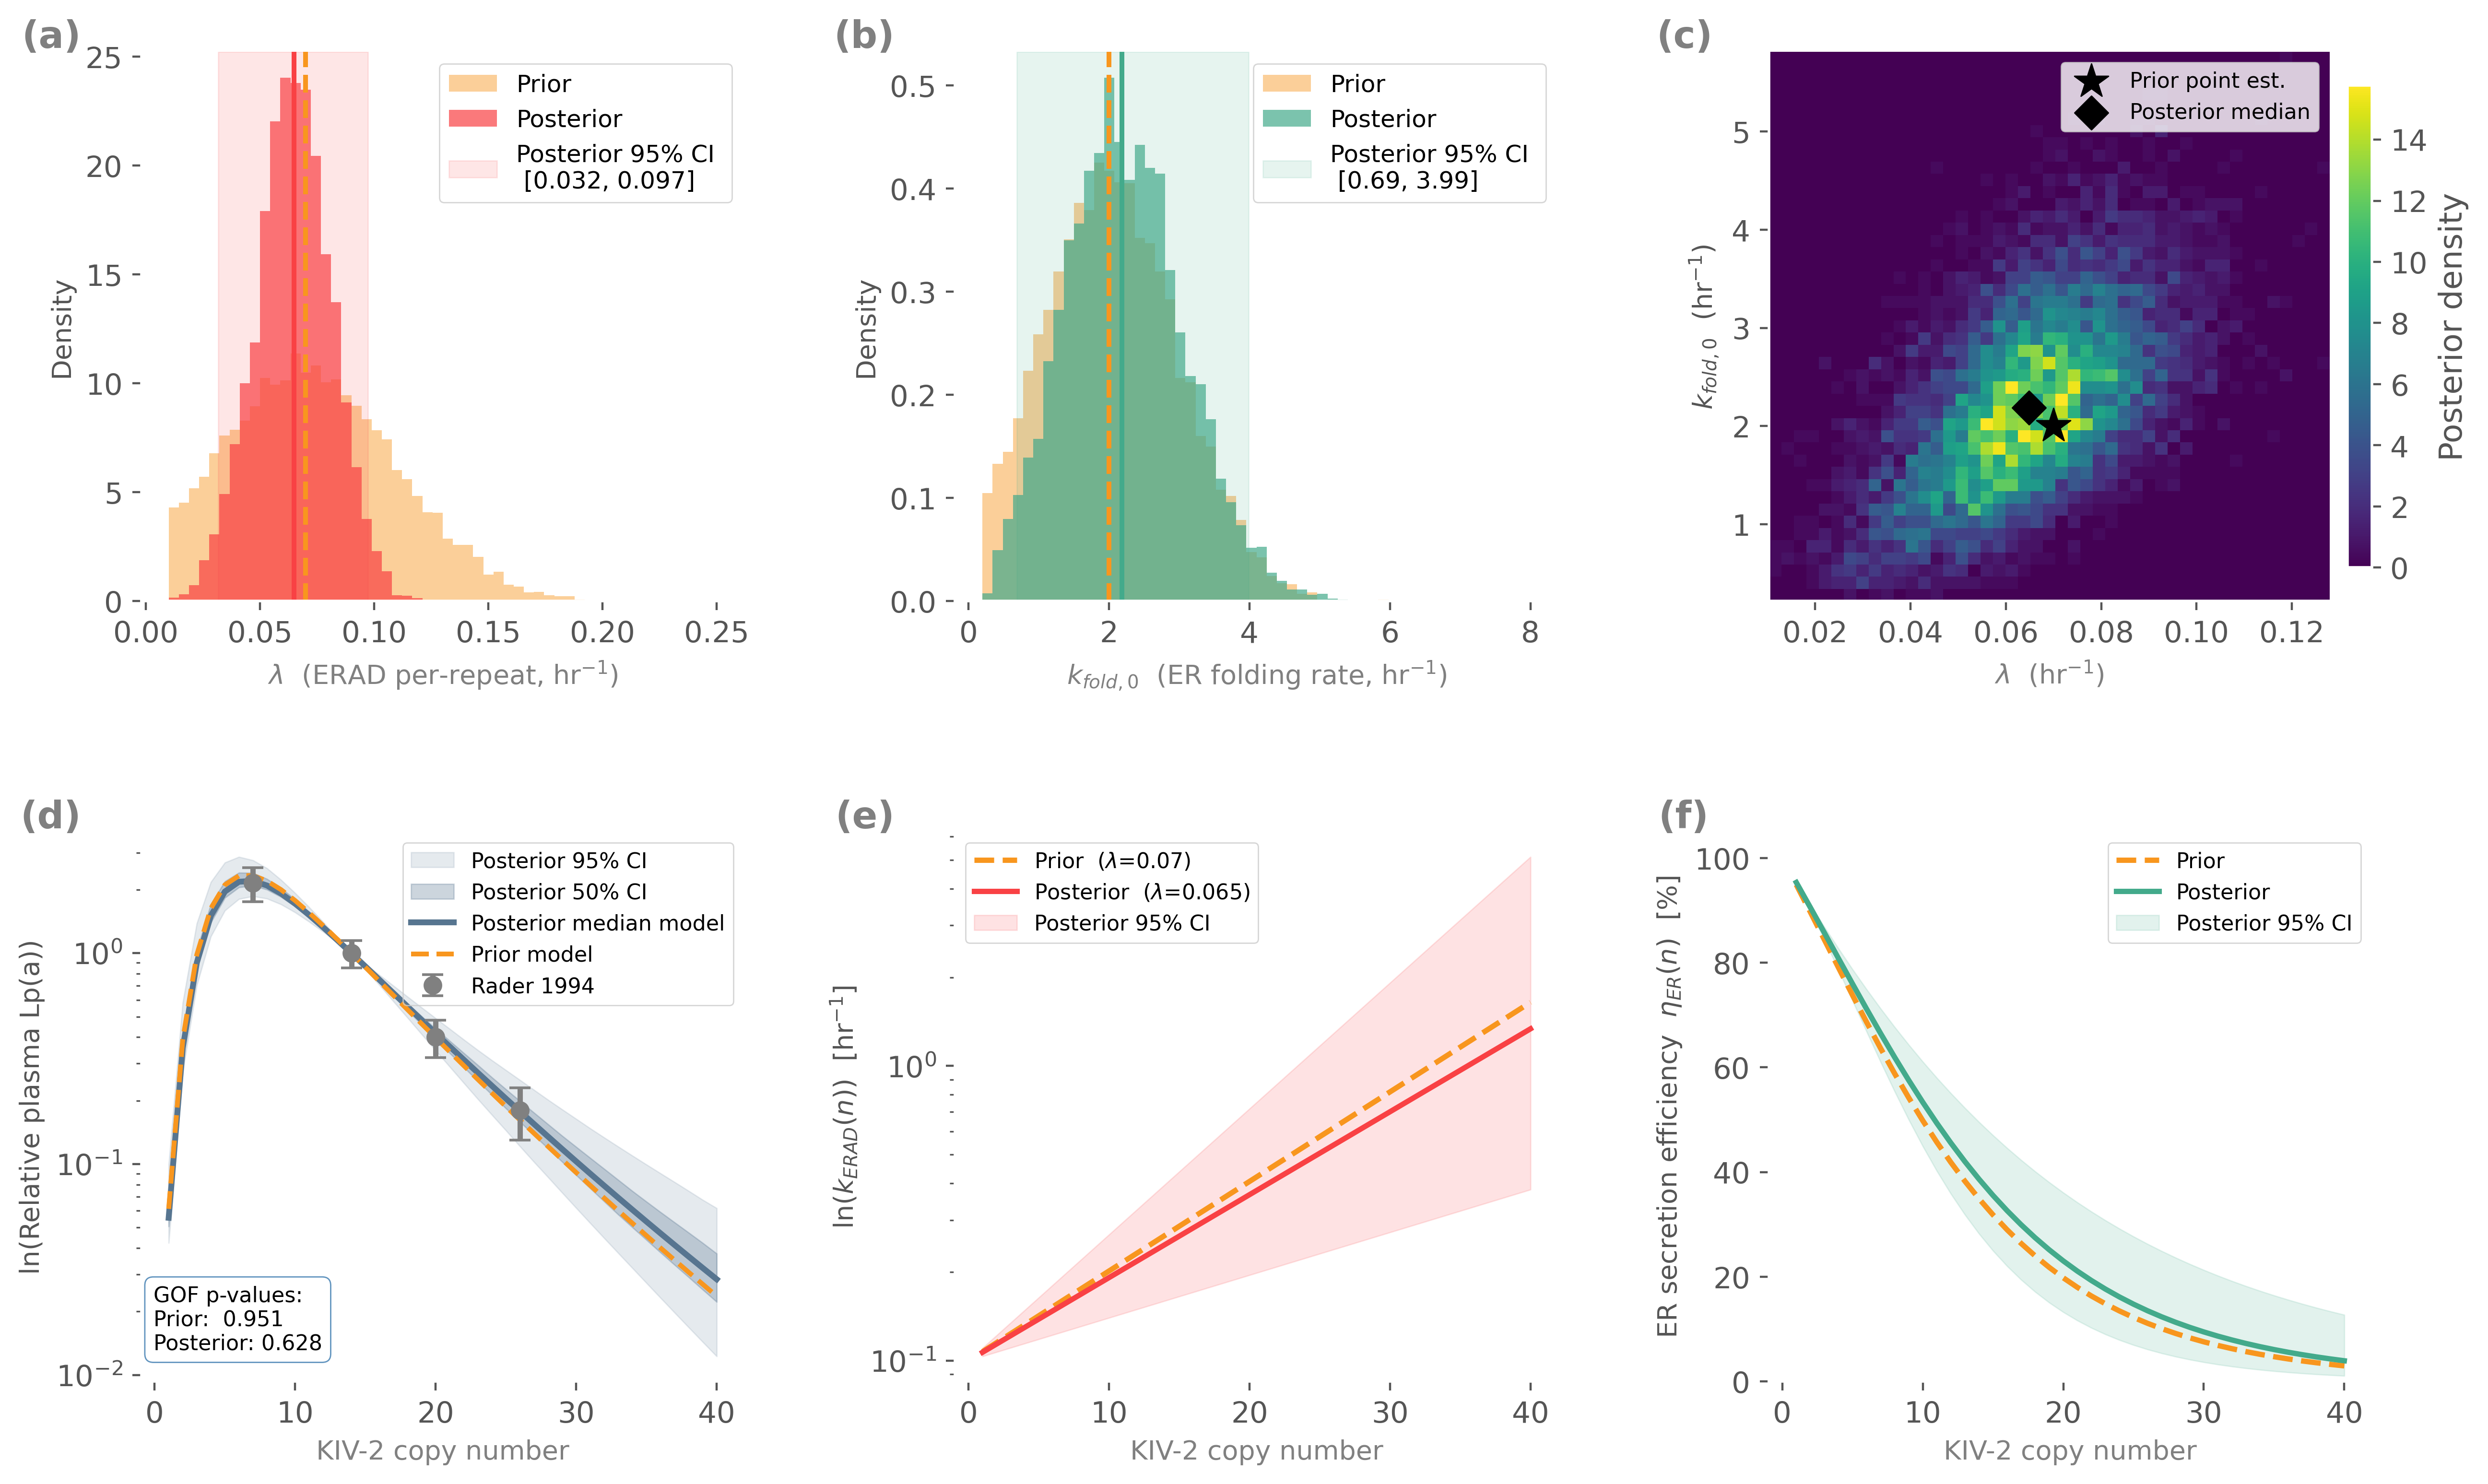

In [16]:
def truncnorm_samples(mu, sigma, lower, upper, n=8000, seed=0):
    """Draw samples from a truncated normal matching PyMC prior spec."""
    a, b = (lower - mu) / sigma, (upper - mu) / sigma
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=n,
                         random_state=seed)

prior_lam     = truncnorm_samples(mu=0.07,  sigma=0.04, lower=0.01, upper=0.25)
prior_k_fold0 = truncnorm_samples(mu=2.0,   sigma=1.0,  lower=0.2,  upper=8.0)

# Use posterior median parameters as the "updated model"
lam_post_med    = float(np.median(post_lam))
kfold_post_med  = float(np.median(post_k_fold0))

params_posterior = {**params,
                    "lam":     lam_post_med,
                    "k_fold0": kfold_post_med}

P_ref_prior = steady_state(14, params)["P"]
P_ref_post  = steady_state(14, params_posterior)["P"]

P_prior_curve = np.array([
    steady_state(int(n), params)["P"] / P_ref_prior for n in n_arr
])
P_post_curve = np.array([
    steady_state(int(n), params_posterior)["P"] / P_ref_post for n in n_arr
])

# Also pull 95% CI bands from fig3 computation (P_lo95, P_hi95, P_med)
# (those were computed over full posterior draws — reuse directly)
n_plot = np.arange(1, 41)

kfold_prior  = np.array([params["k_fold0"] / n for n in n_plot])
kfold_post   = np.array([params_posterior["k_fold0"] / n for n in n_plot])

kerad_prior  = np.array([params["k_e"] * np.exp(params["lam"] * n)
                          for n in n_plot])
kerad_post   = np.array([params_posterior["k_e"] *
                          np.exp(params_posterior["lam"] * n)
                          for n in n_plot])

eta_prior    = kfold_prior / (kfold_prior + kerad_prior)
eta_post     = kfold_post  / (kfold_post  + kerad_post)

fig, axes = plt.subplots(2, 3, figsize=(15, 9),
                          gridspec_kw={"hspace": 0.42, "wspace": 0.35})

panel_letters = [["(a)", "(b)", "(c)"],
                 ["(d)", "(e)", "(f)"]]

# ── (a) λ prior vs posterior ──────────────────────────────────────────────────
ax = axes[0, 0]
lam_bins = np.linspace(0.01, 0.25, 55)
ax.hist(prior_lam,    bins=lam_bins, density=True, alpha=0.45,
        color=COLORS[2], label="Prior")
ax.hist(post_lam,     bins=lam_bins, density=True, alpha=0.70,
        color=COLORS[0], label="Posterior")
ax.axvline(params["lam"],    color=COLORS[2], lw=1.8, ls="--")
ax.axvline(lam_post_med,     color=COLORS[0], lw=1.8, ls="-")
lam_lo95, lam_hi95 = np.percentile(post_lam, [2.5, 97.5])
ax.axvspan(lam_lo95, lam_hi95, alpha=0.13, color=COLORS[0],
           label=f"Posterior 95% CI \n [{lam_lo95:.3f}, {lam_hi95:.3f}]")
ax.set_xlabel(r"$\lambda$  (ERAD per-repeat, hr$^{-1}$)",
              fontsize=10, color="gray")
ax.set_ylabel("Density", fontsize=10)
ax.legend(fontsize=9)
# ax.set_title(rf"Prior → Posterior:  $\lambda$  "
#              rf"({params['lam']:.2f} → {lam_post_med:.3f})",
#              fontsize=9, color="gray")
letter_tag(ax, "(a)")

# ── (b) k_fold0 prior vs posterior ────────────────────────────────────────────
ax = axes[0, 1]
kf_bins = np.linspace(0.2, 8.0, 55)
ax.hist(prior_k_fold0, bins=kf_bins, density=True, alpha=0.45,
        color=COLORS[2], label="Prior")
ax.hist(post_k_fold0,  bins=kf_bins, density=True, alpha=0.70,
        color=COLORS[6], label="Posterior")
ax.axvline(params["k_fold0"],  color=COLORS[2], lw=1.8, ls="--")
ax.axvline(kfold_post_med,     color=COLORS[6], lw=1.8, ls="-")
kf_lo95, kf_hi95 = np.percentile(post_k_fold0, [2.5, 97.5])
ax.axvspan(kf_lo95, kf_hi95, alpha=0.13, color=COLORS[6],
           label=f"Posterior 95% CI \n [{kf_lo95:.2f}, {kf_hi95:.2f}]")
ax.set_xlabel(r"$k_{fold,0}$  (ER folding rate, hr$^{-1}$)",
              fontsize=10, color="gray")
ax.set_ylabel("Density", fontsize=10)
ax.legend(fontsize=9)
# ax.set_title(rf"Prior → Posterior:  $k_{{fold,0}}$  "
#              rf"({params['k_fold0']:.1f} → {kfold_post_med:.2f})",
#              fontsize=9, color="gray")
letter_tag(ax, "(b)")

# ── (c) Joint posterior: λ vs k_fold0 ────────────────────────────────────────
ax = axes[0, 2]
h = ax.hist2d(post_lam, post_k_fold0, bins=45,
              cmap="viridis", density=True)
fig.colorbar(h[3], ax=ax, fraction=0.04, pad=0.03,
             label="Posterior density")
ax.scatter(params["lam"], params["k_fold0"],
           marker="*", s=180, color="black", zorder=5,
           label="Prior point est.")
ax.scatter(lam_post_med, kfold_post_med,
           marker="D", s=80, color="black", zorder=5,
           label="Posterior median")
ax.set_xlabel(r"$\lambda$  (hr$^{-1}$)",
              fontsize=10, color="gray")
ax.set_ylabel(r"$k_{fold,0}$  (hr$^{-1}$)", fontsize=10)
ax.legend(fontsize=8, loc="upper right", facecolor="white")
# ax.set_title(r"Joint posterior  $(\lambda,\, k_{fold,0})$",
#              fontsize=9, color="gray")
letter_tag(ax, "(c)")

# ── (d) P_ss(n): prior model vs posterior model vs Rader 1994 ─────────────────
ax = axes[1, 0]
ax.fill_between(n_arr, P_lo95, P_hi95,
                alpha=0.15, color=COLORS[8], label="Posterior 95% CI")
ax.fill_between(n_arr, P_lo50, P_hi50,
                alpha=0.30, color=COLORS[8], label="Posterior 50% CI")
ax.plot(n_arr, P_post_curve, color=COLORS[8], lw=2.2,
        label="Posterior median model")
ax.plot(n_arr, P_prior_curve, color=COLORS[2], lw=1.8, ls="--",
        label="Prior model")
ax.errorbar(obs_n_r, obs_PR_r, yerr=obs_err_r,
            fmt="o", color="gray", ms=6, capsize=4, zorder=6,
            label="Rader 1994")
ax.set_yscale("log")
ax.set_xlabel("KIV-2 copy number",
              fontsize=10, color="gray")
ax.set_ylabel(r"ln(Relative plasma Lp(a))", fontsize=10)
ax.legend(fontsize=8, loc="upper right")

# Include chi-squared GOF p-value annotation for both prior and posterior models
prior_pred = np.array([steady_state(int(n), params)["P"] / ref_ss["P"] for n in obs_n_r])
post_pred  = np.array([steady_state(int(n), params_posterior)["P"] / ref_ss["P"] for n in obs_n_r])
chi2_prior, p_prior = chi2_gof_p_value(obs_PR_r, prior_pred, obs_err_r)
chi2_post,  p_post  = chi2_gof_p_value(obs_PR_r, post_pred,  obs_err_r)
gof_text = (f"GOF p-values:\n"
            f"Prior:  {p_prior:.3f}\n"
            f"Posterior: {p_post:.3f}")
ax.text(0.02, 0.05, gof_text, transform=ax.transAxes, fontsize=8,
        va="bottom", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="steelblue", alpha=0.85))

print(f"Chi-squared GOF:\n"
      f"Prior model: chi2={chi2_prior:.2f}, p={p_prior:.3f}\n"
      f"Posterior model: chi2={chi2_post:.2f}, p={p_post:.3f}")
# ax.set_title(r"$P_{ss}(n)$: prior vs posterior model fit",
#              fontsize=9, color="gray")
letter_tag(ax, "(d)")

# ── (e) ERAD rate k_ERAD(n): prior vs posterior ───────────────────────────────
ax = axes[1, 1]
ax.semilogy(n_plot, kerad_prior, color=COLORS[2], lw=2, ls="--",
            label=rf"Prior  ($\lambda$={params['lam']:.2f})")
ax.semilogy(n_plot, kerad_post,  color=COLORS[0], lw=2,
            label=rf"Posterior  ($\lambda$={lam_post_med:.3f})")

# shade uncertainty band from posterior draws
kerad_draws = np.array([
    [params["k_e"] * np.exp(float(post_lam[i]) * n) for n in n_plot]
    for i in rng.choice(len(post_lam), 500, replace=False)
])
ax.fill_between(n_plot,
                np.percentile(kerad_draws, 2.5, axis=0),
                np.percentile(kerad_draws, 97.5, axis=0),
                alpha=0.15, color=COLORS[0], label="Posterior 95% CI")
ax.set_xlabel("KIV-2 copy number",
              fontsize=10, color="gray")
ax.set_ylabel(r"ln($k_{ERAD}(n)$)  [hr$^{-1}$]", fontsize=10)
ax.legend(fontsize=8)
# ax.set_title(r"ERAD rate $k_{ERAD}(n) = k_e \cdot e^{\lambda n}$",
#              fontsize=9, color="gray")
letter_tag(ax, "(e)")

# ── (f) ER secretion efficiency η(n): prior vs posterior ─────────────────────
ax = axes[1, 2]
ax.plot(n_plot, eta_prior * 100, color=COLORS[2], lw=2, ls="--",
        label="Prior")
ax.plot(n_plot, eta_post  * 100, color=COLORS[6], lw=2,
        label="Posterior")

eta_draws = np.array([
    [
        (params_posterior["k_fold0"] / n) /
        ((params_posterior["k_fold0"] / n) +
         params["k_e"] * np.exp(float(post_lam[i]) * n))
        for n in n_plot
    ]
    for i in rng.choice(len(post_lam), 500, replace=False)
])
ax.fill_between(n_plot,
                np.percentile(eta_draws * 100, 2.5,  axis=0),
                np.percentile(eta_draws * 100, 97.5, axis=0),
                alpha=0.15, color=COLORS[6], label="Posterior 95% CI")
ax.set_ylim(0, 105)
ax.set_xlabel("KIV-2 copy number",
              fontsize=10, color="gray")
ax.set_ylabel(r"ER secretion efficiency  $\eta_{ER}(n)$  [%]", fontsize=10)
ax.legend(fontsize=8)
# ax.set_title(r"$\eta_{ER}(n)$: prior vs posterior",
#              fontsize=9, color="gray")
letter_tag(ax, "(f)")

plt.savefig("figures/fig2_prior_posterior_comparison.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Figure 3

/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_52644/3717823128.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


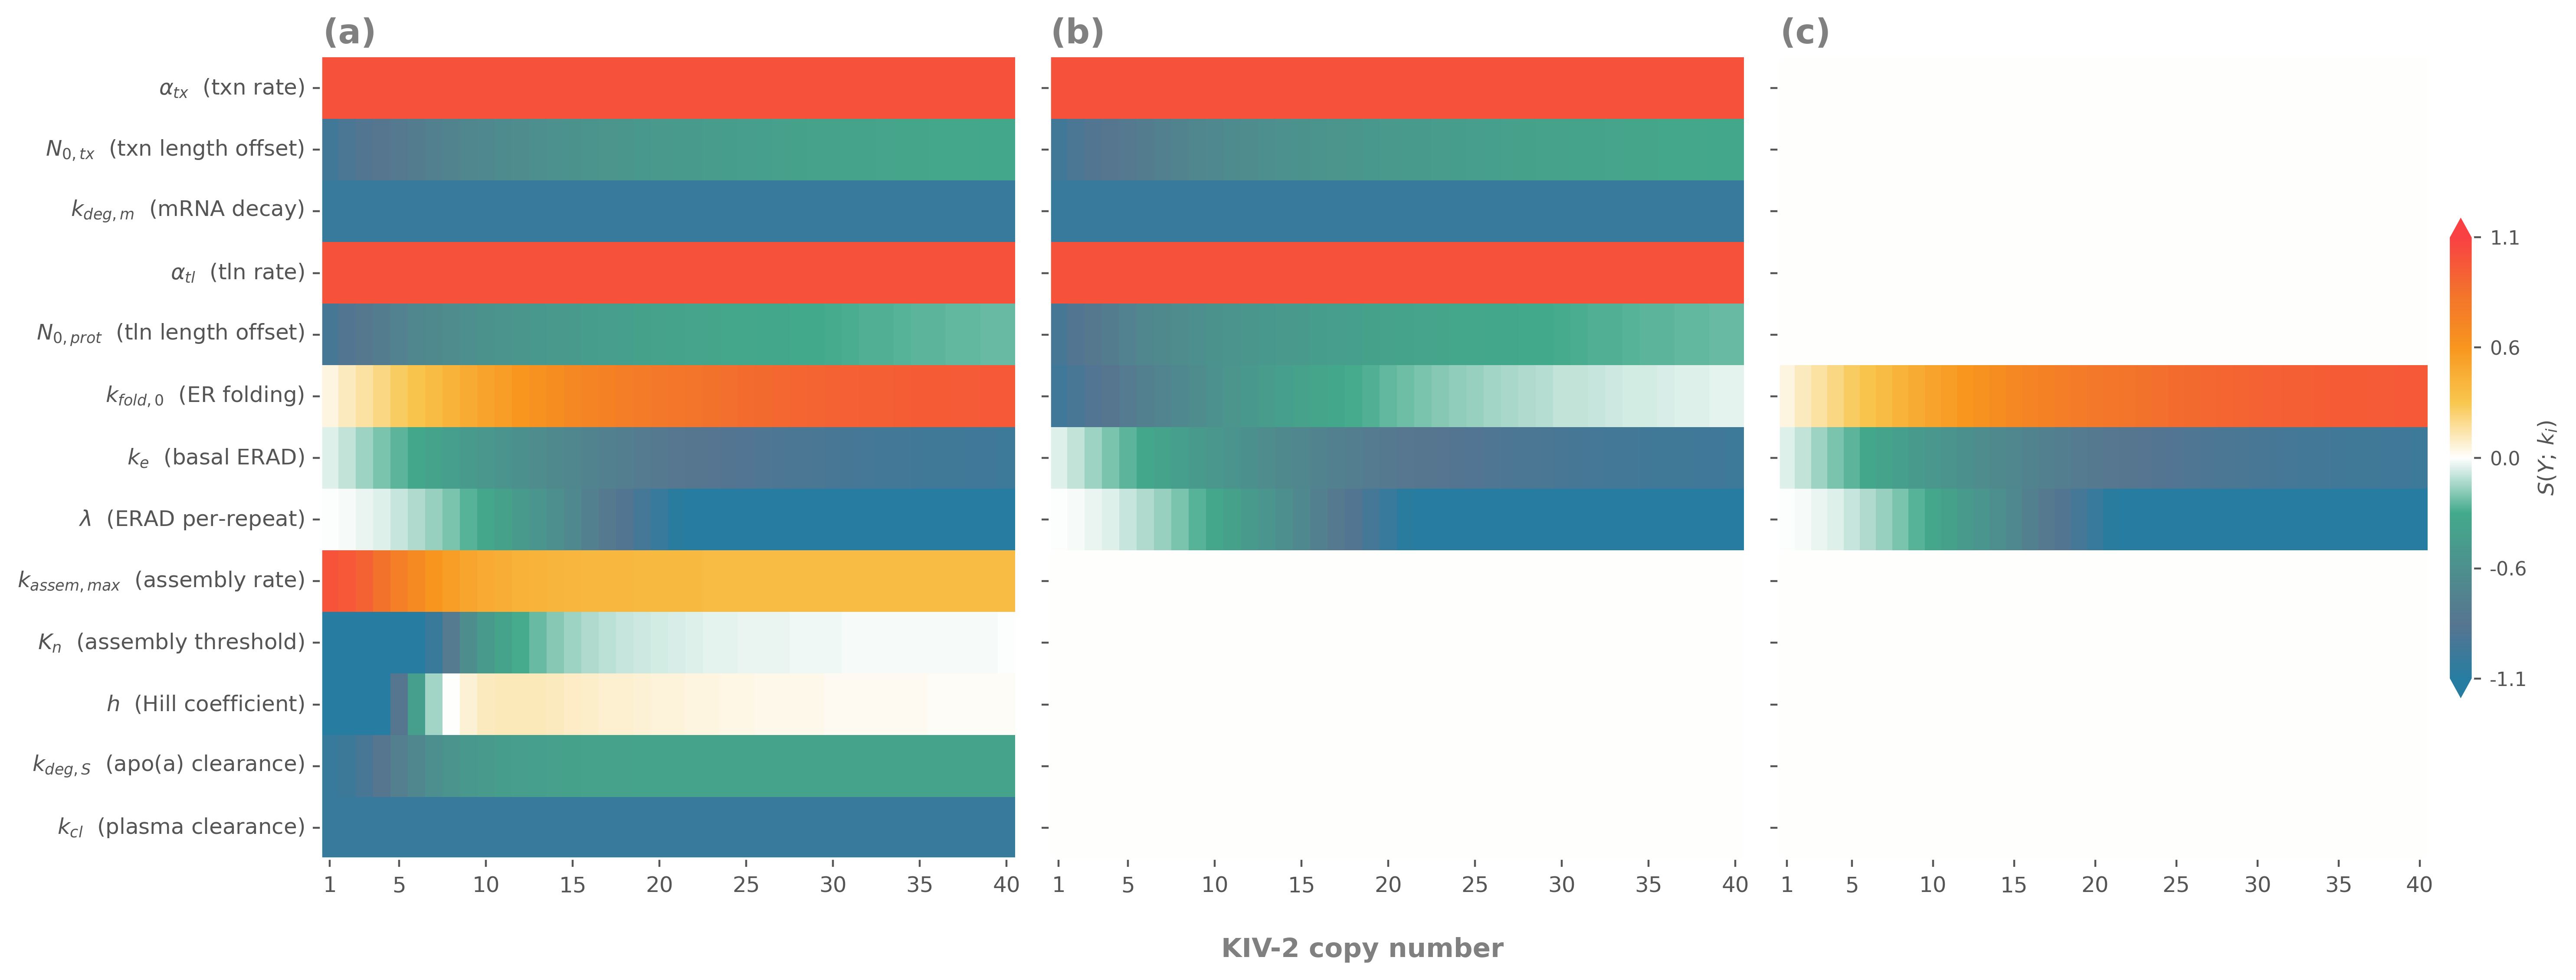

In [18]:
# ── Figure 3 : Normalized local parameter sensitivity — posterior parameters ──

DELTA = 0.10

PARAM_KEYS = [
    "alpha_tx", "N0_tx", "k_deg_m",
    "alpha_tl", "N0_prot",
    "k_fold0",
    "k_e", "lam",
    "k_assem_max", "K_n_assem", "h_assem",
    "k_deg_S", "k_cl",
]

PARAM_LABELS = {
    "alpha_tx":    r"$\alpha_{tx}$  (txn rate)",
    "N0_tx":       r"$N_{0,tx}$  (txn length offset)",
    "k_deg_m":     r"$k_{deg,m}$  (mRNA decay)",
    "alpha_tl":    r"$\alpha_{tl}$  (tln rate)",
    "N0_prot":     r"$N_{0,prot}$  (tln length offset)",
    "k_fold0":     r"$k_{fold,0}$  (ER folding)",
    "k_e":         r"$k_e$  (basal ERAD)",
    "lam":         r"$\lambda$  (ERAD per-repeat)",
    "k_assem_max": r"$k_{assem,max}$  (assembly rate)",
    "K_n_assem":   r"$K_n$  (assembly threshold)",
    "h_assem":     r"$h$  (Hill coefficient)",
    "k_deg_S":     r"$k_{deg,S}$  (apo(a) clearance)",
    "k_cl":        r"$k_{cl}$  (plasma clearance)",
}

def compute_sensitivity(output_key="P", delta=DELTA, p=params_posterior):
    S_mat = np.zeros((len(PARAM_KEYS), len(n_arr)))
    for pi, pk in enumerate(PARAM_KEYS):
        base_val = p[pk]
        for ni, n in enumerate(n_arr):
            p_hi = {**p, pk: base_val * (1 + delta / 2)}
            p_lo = {**p, pk: base_val * (1 - delta / 2)}
            Y_hi = steady_state(int(n), p_hi)[output_key]
            Y_lo = steady_state(int(n), p_lo)[output_key]
            Y_0  = steady_state(int(n), p)[output_key]
            if Y_0 != 0 and np.isfinite(Y_0):
                S_mat[pi, ni] = (Y_hi - Y_lo) / (delta * Y_0)
            else:
                S_mat[pi, ni] = np.nan
    return S_mat

S_P   = compute_sensitivity("P")
S_E   = compute_sensitivity("E")
S_eta = compute_sensitivity("eta")
S_MATS = [S_P, S_E, S_eta]

all_vals = np.concatenate([S.flatten() for S in S_MATS])
abs_max_global = np.ceil(np.nanpercentile(np.abs(all_vals), 95) * 10) / 10

_neg = [COLORS[9], COLORS[8], COLORS[7], COLORS[6]]
_pos = [COLORS[4], COLORS[2], COLORS[1], COLORS[0]]
cmap = LinearSegmentedColormap.from_list(
    "lpa_sensitivity", _neg + ["#ffffff"] + _pos, N=256)

OUTPUT_LABELS = [
    r"$P_{ss}(n)$  — Plasma Lp(a)",
    r"$E_{ss}(n)$  — ER apo(a) load",
    r"$\eta_{ER}(n)$  — ER secretion efficiency",
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6),
                         gridspec_kw={"wspace": 0.05})

ims = []
for col, (ax, S_mat, col_label) in enumerate(zip(axes, S_MATS, OUTPUT_LABELS)):

    im = ax.imshow(
        S_mat,
        aspect="auto",
        cmap=cmap,
        vmin=-abs_max_global,
        vmax= abs_max_global,
        interpolation="nearest",
    )
    ims.append(im)

    xtick_pos = [i for i, n in enumerate(n_arr)
                 if n in [1, 5, 10, 15, 20, 25, 30, 35, 40]]
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels([str(n_arr[i]) for i in xtick_pos], fontsize=9)

    ax.set_yticks(range(len(PARAM_KEYS)))
    if col == 0:
        ax.set_yticklabels(
            [PARAM_LABELS[pk] for pk in PARAM_KEYS],
            fontsize=9, rotation=0, va="center", ha="right",
        )
    else:
        ax.set_yticklabels([])

    letter = ["(a)", "(b)", "(c)"][col]
    ax.text(0.08, 1.05, letter, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="right", color="gray")
    # ax.set_title(col_label, fontsize=10, pad=6, color="gray")

cbar = fig.colorbar(ims[2], ax=axes[2], fraction=0.035, pad=0.03,
                    orientation="vertical", extend="both")
cbar.set_label(r"$S(Y;\,k_i)$", fontsize=9)
cbar.ax.tick_params(labelsize=8)
ticks = [-abs_max_global, -abs_max_global / 2, 0,
          abs_max_global / 2,  abs_max_global]
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{v:.1f}" for v in ticks])

fig.supxlabel("KIV-2 copy number", fontsize=11, fontweight="bold", color="gray")
plt.tight_layout()
plt.savefig("figures/fig3_sensitivity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 4

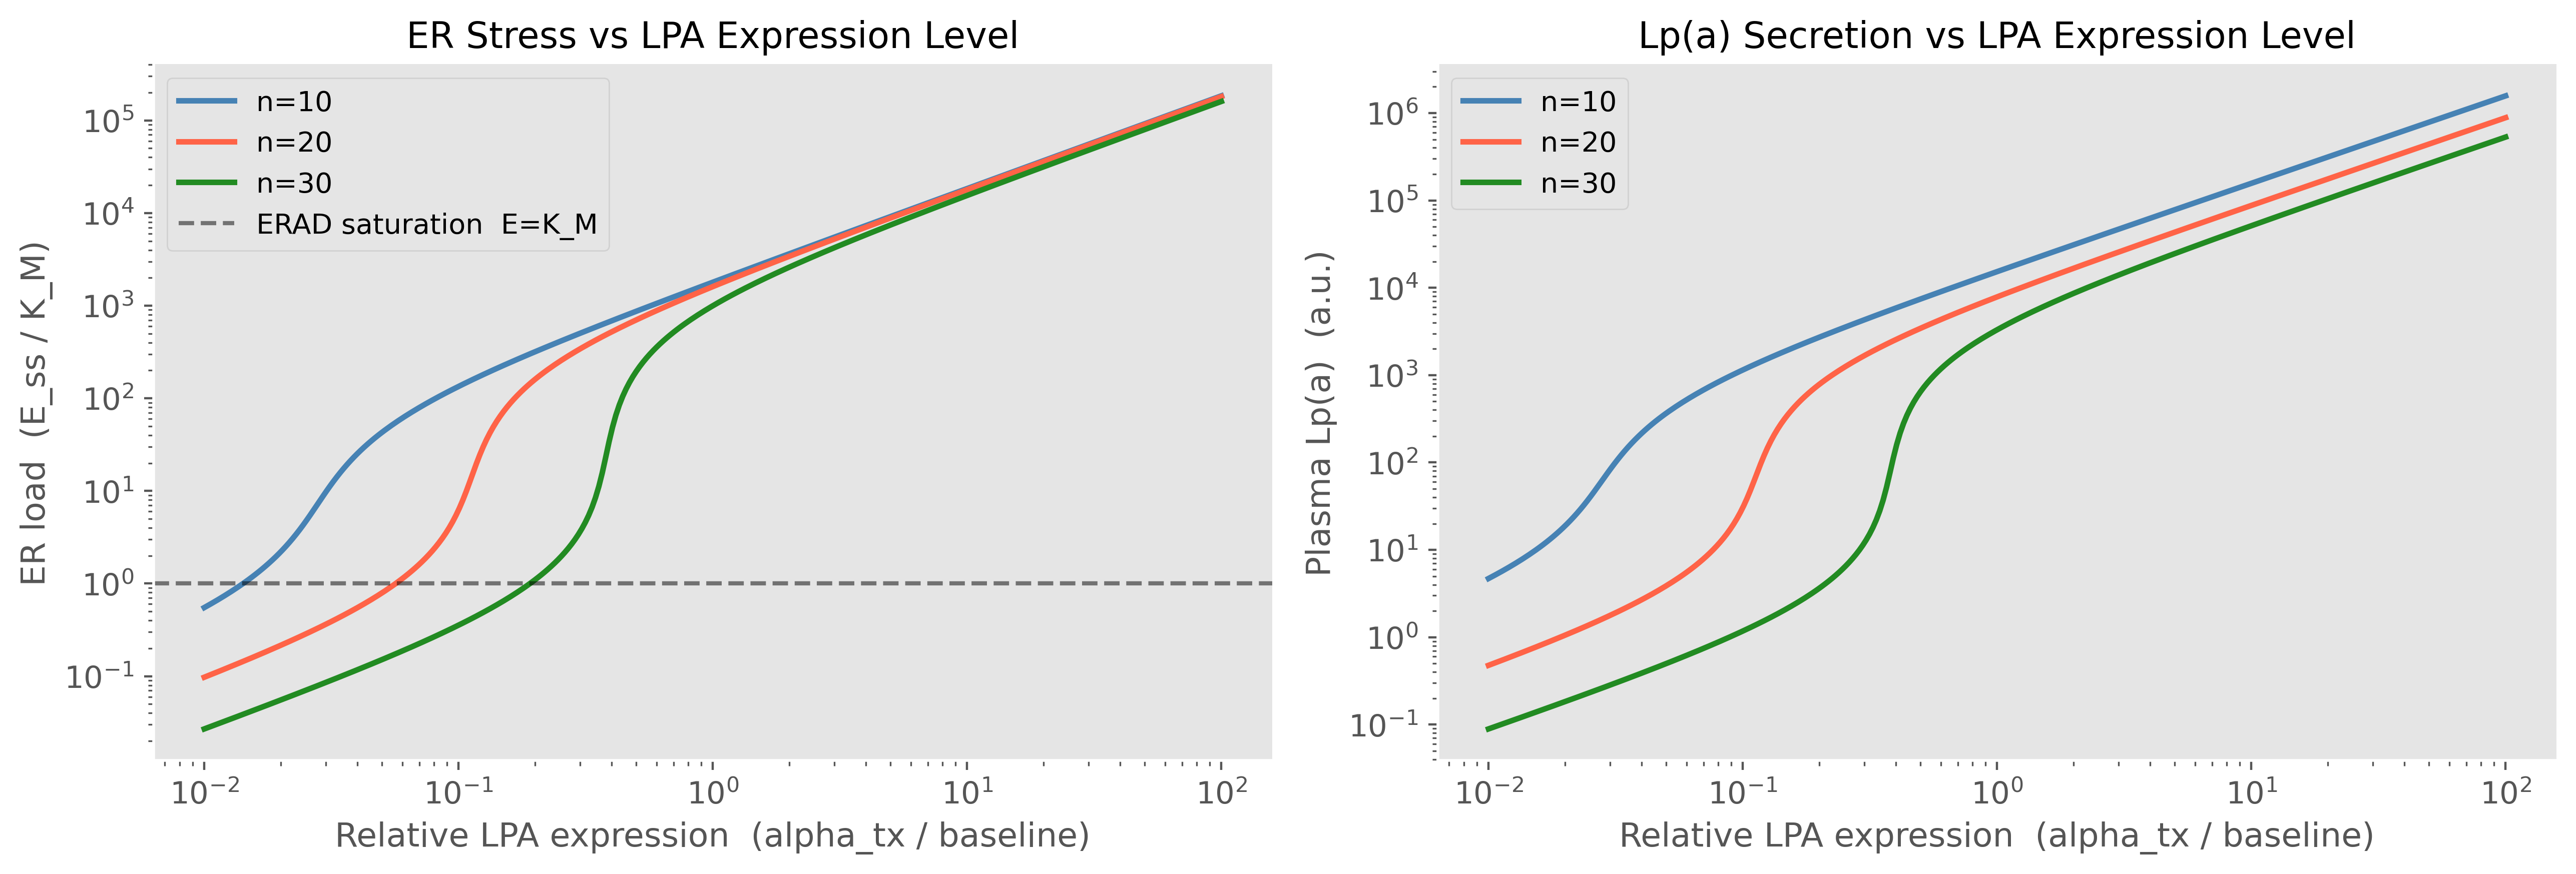

In [ ]:
# Figure 4 : Bifurcation — ER load vs expression level
N_BIF      = [10, 20, 30]
bif_colors = ["steelblue", "tomato", "forestgreen"]
atx_fac    = np.logspace(-2, 2, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for n_b, col in zip(N_BIF, bif_colors):
    E_arr, P_arr = [], []
    for fac in atx_fac:
        p_tmp = dict(params)
        p_tmp["alpha_tx"] = params["alpha_tx"] * fac
        s = steady_state_mm(n_b, p_tmp)
        E_arr.append(s["E"])
        P_arr.append(s["P"])

    E_rel = np.array(E_arr) / params["K_M_ERAD"]
    axes[0].plot(atx_fac, E_rel,           color=col, label=f"n={n_b}")
    axes[1].plot(atx_fac, np.array(P_arr), color=col, label=f"n={n_b}")

axes[0].axhline(1.0, color="k", ls="--", lw=1.5, alpha=0.5, label="ERAD saturation  E=K_M")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Relative LPA expression  (alpha_tx / baseline)")
axes[0].set_ylabel("ER load  (E_ss / K_M)")
axes[0].set_title("ER Stress vs LPA Expression Level")
axes[0].legend(fontsize=10)

axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Relative LPA expression  (alpha_tx / baseline)")
axes[1].set_ylabel("Plasma Lp(a)  (a.u.)")
axes[1].set_title("Lp(a) Secretion vs LPA Expression Level")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("figures/fig4_erad_bifurcation.png", dpi=150, bbox_inches="tight")
plt.show()